# NGS emergency response imagery

After a hurricane, flood, fire, or tornado, NOAA's National Geodetic Survey
flies the damaged area, mosaics its aerial photographs, and cuts the mosaic
into GeoTIFF tiles, which it publishes in the public `noaa-eri-pds` S3 bucket.
One file is one tile of one flight: red, green, and blue at 15 to 35 cm per
pixel, over a square about 1.4 to 2.8 km on a side, named for its north-west
corner. Of the bucket's 52 events, only three are tornadoes.

This walkthrough takes the tile over Germantown, just north of downtown
Nashville, from the flight NGS made four days after the tornado of 3 March
2020. usdata has no GeoTIFF reader, so the notebook opens the file's built-in
overviews with Pillow, which matplotlib installs. It downloads one file of
about 59 MB and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import PIL
from PIL import Image

import usdata
from usdata import cite_lockfile, pull, verify
from usdata.readers import UnsupportedFormat

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(
    f"usdata {usdata.__version__}; Pillow {PIL.__version__}; "
    f"matplotlib {matplotlib.__version__}; NumPy {np.__version__}"
)

Executed (UTC): 2026-09-29T23:41:16+00:00
usdata 0.33.0; Pillow 12.3.0; matplotlib 3.11.2; NumPy 2.5.2


## Select

The manifest names the event folder exactly as the bucket names it,
`2020_Nashville_Tornado`, and its one flight folder, `20200307a_RGB`: flight
folders are named for the flight's local date and a letter for each flight
that day. The box around Germantown selects by footprint. Each tile's name
gives its north-west corner, and the header of the folder's first tile, read
with one small range request, gives the size of every tile in the folder, 90
arc-seconds here. Each footprint is widened by two arc-seconds, since some names
round a corner down, so a tile that nearly touches the box would be kept too.

There is no time window: the folder dates are local, and some events' folders
have none. Without the box, this flight is 163 tiles and 7.1 GB; a selection
over 25 GB is refused, with where its bytes are, unless `max_gb` allows it.

In [2]:
print(manifest.read_text())

name: nashville-tornado-germantown
sources:
  - dataset: noaa:emergency-response-imagery
    bbox: {west: -86.795, south: 36.177, east: -86.785, north: 36.185}
    params:
      event: 2020_Nashville_Tornado
      collection: 20200307a_RGB



## What arrives

One GeoTIFF, named for the flight and the tile's corner, 86°48'00"W
36°12'00"N. The asset's `bbox` is the footprint it was selected by. Its `time`
is 7 March 2020 in local time anywhere in the United States: from 04:00 UTC
that day to 10:00 UTC the next.

In [3]:
result = pull(manifest)
(item,) = result.fetched
asset = item.asset
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Footprint (W, S, E, N):", tuple(round(value, 5) for value in asset.bbox.as_tuple()))
print("Time (UTC):", asset.time.start.isoformat(), "to", asset.time.end.isoformat())

File: 2020_Nashville_Tornado_20200307a_RGB_20200307aC0864800w361200n.tif
Bytes: 58670760
Source: s3://noaa-eri-pds/2020_Nashville_Tornado/20200307a_RGB/20200307aC0864800w361200n.tif
Retrieved (UTC): 2026-09-29T23:41:19+00:00
Checksum: sha256:d0011c8c3e9201af98947bf491c4e44be2ffbf812c7b1afe2f43004a18401b6f
Footprint (W, S, E, N): (-86.80056, 36.17424, -86.77424, 36.20056)
Time (UTC): 2020-03-07T04:00:00+00:00 to 2020-03-08T10:00:00+00:00


## Open

`open()` raises `UnsupportedFormat`: usdata reads no GeoTIFFs, and the catalog
entry's reader is empty. Pillow opens the file, which holds one image per
resolution: the full 18,681-pixel square, then overviews each half the size of
the one before, all JPEG-compressed. Between them are one-bit transparency
masks that Pillow cannot read, so the loop below skips them; Pillow's
`n_frames` fails on them too.

In [4]:
try:
    item.open()
except UnsupportedFormat as error:
    print(error)

Image.MAX_IMAGE_PIXELS = None  # The full image is 349 million pixels; only overviews are decoded.
image = Image.open(item.path)
levels = {}
index = 0
while True:
    try:
        image.seek(index)
    except EOFError:
        break
    except SyntaxError:
        pass  # A transparency mask.
    else:
        levels[image.size[0]] = index
        print(f"image {index:2d}: {image.size[0]:>6,} x {image.size[1]:>6,} {image.mode}")
    index += 1

no reader for 'image/tiff; application=geotiff'; supported formats are CSV, ERDDAP CSV, NetCDF4, GRIB2, NEXRAD Level II, HURDAT2 best tracks, AQS daily JSON, and ACS tables. For a CSV with ambiguous metadata, use open_csv; otherwise use fetched.path with a format-specific reader
image  0: 18,681 x 18,681 RGB
image  2:  9,341 x  9,341 RGB
image  3:  4,671 x  4,671 RGB
image  4:  2,336 x  2,336 RGB
image  5:  1,168 x  1,168 RGB
image  6:    584 x    584 RGB
image  7:    292 x    292 RGB
image  8:    146 x    146 RGB


The GeoTIFF tags place the image. `ModelTiepoint` ties its top-left pixel
corner to a longitude and latitude, 0.0001° outside the corner the name gives,
and `ModelPixelScale` gives the size of one full-resolution pixel in degrees.

In [5]:
image.seek(0)
tiepoint, scale = image.tag_v2[33922], image.tag_v2[33550]
west, north = tiepoint[3], tiepoint[4]
width, height = image.size
east, south = west + scale[0] * width, north - scale[1] * height
latitude = np.radians((north + south) / 2)
print(f"Image: {west:.4f} to {east:.4f} °E, {south:.4f} to {north:.4f} °N")
print("Name's corner: -86.8000 °E, 36.2000 °N")
print(
    f"Pixel: {scale[0]:.3e}°, {scale[0] * 111_320 * np.cos(latitude):.2f} m east-west "
    f"and {scale[1] * 110_950:.2f} m north-south"
)

Image: -86.8001 to -86.7749 °E, 36.1749 to 36.2001 °N
Name's corner: -86.8000 °E, 36.2000 °N
Pixel: 1.349e-06°, 0.12 m east-west and 0.15 m north-south


## A first look

On the left, the whole tile from its 1,168-pixel overview, with the query box
in orange; on the right, the box from the 4,671-pixel overview, about half a
metre per pixel. Both are drawn in longitude and latitude with the aspect of
this latitude, so the tile, square in degrees, is taller than it is wide.

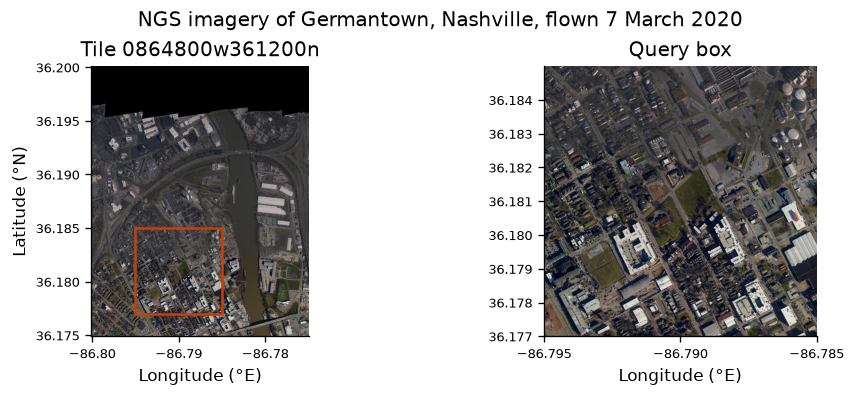

In [6]:
def overview(size: int) -> np.ndarray:
    """The overview ``size`` pixels wide, decoded to an RGB array."""
    image.seek(levels[size])
    return np.asarray(image.convert("RGB"))


box = asset.bbox
query = (-86.795, 36.177, -86.785, 36.185)
whole, detail = overview(1168), overview(4671)
step = (east - west) / detail.shape[1]
columns = slice(round((query[0] - west) / step), round((query[2] - west) / step))
rows = slice(round((north - query[3]) / step), round((north - query[1]) / step))
fig, (left, right) = plt.subplots(1, 2, figsize=(8, 3.2), layout="constrained")
left.imshow(whole, extent=(west, east, south, north))
left.add_patch(
    plt.Rectangle(
        (query[0], query[1]),
        query[2] - query[0],
        query[3] - query[1],
        fill=False,
        edgecolor="#c2410c",
        linewidth=1.5,
    )
)
right.imshow(
    detail[rows, columns],
    extent=(
        west + columns.start * step,
        west + columns.stop * step,
        north - rows.stop * step,
        north - rows.start * step,
    ),
)
for ax, title in ((left, "Tile 0864800w361200n"), (right, "Query box")):
    ax.set_aspect(1 / np.cos(latitude))
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("Longitude (°E)")
    ax.tick_params(labelsize=8)
    ax.locator_params(axis="x", nbins=3)
left.set_ylabel("Latitude (°N)")
fig.suptitle("NGS imagery of Germantown, Nashville, flown 7 March 2020")
plt.show()

In [7]:
pixels = whole.reshape(-1, 3)
empty = (pixels.max(axis=1) == 0).mean()
print(f"Black, unimaged pixels in the overview: {empty:.0%}")
print(f"Full image decoded: {width * height * 3 / 1e9:.2f} GB of RGB")

Black, unimaged pixels in the overview: 17%
Full image decoded: 1.05 GB of RGB


The tile's top edge is beyond the flight, and JPEG tiles have no transparency
band, so ground the flight did not cover is black. The Cumberland River runs
through the tile, with Germantown's grid of streets west of it. At half a metre
per pixel roofs and streets are clear; judging the damage to a roof needs the
full image, four times finer, which Pillow can decode too at the cost of
about a gigabyte of memory.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a methods
section needs, and `usdata cite dataset.yaml` prints the same. NGS also
publishes a citation per event, in its InPort record, which the dataset guide
links.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:emergency-response-imagery
  National Geodetic Survey, NOAA Emergency Response Imagery, accessed via usdata from https://registry.opendata.aws/noaa-eri
  homepage: https://storms.ngs.noaa.gov/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-29; 1 checksummed asset (58,670,760 bytes) pinned by usdata 0.33.0
  sources: 1


## What was awkward

- There is no reader. Pillow is enough to look at an overview, but analysis
  in map coordinates needs GDAL or rasterio, neither an extra, and Pillow
  cannot read the transparency masks or count the images in the file.
- A bbox costs a header read for each folder, and it is refused outright for
  events whose files are numbered or oblique frames, such as Hurricane Wilma
  or Hurricane Matthew's oblique flights; there, name the tiled flights with
  `collection`.
- The name is not quite the corner of the pixels: tiles extend 0.0001° past
  it, and some names round a second down, which is why footprints are widened
  and a tile beside the box can come along.
- Time is a 30-hour UTC interval, because the folder gives a local date and
  nothing gives a time zone or an hour; start and end cannot select flights.
- Tiles are large and grow: this one is 59 MB, and tiles flown since 2021
  reach 1.7 GB. The dry run's byte count, and the 25 GB `max_gb` refusal, are
  worth reading before fetching a whole event.
- Asset ids are whole bucket keys, since two folders can hold files of the
  same name, so the cached file name carries the event and flight with
  underscores for the slashes.

See the [dataset guide](https://docs.usdata.dev/providers/noaa-emergency-response-imagery/)
for every event, file-naming scheme, and refusal.